In [15]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort

In [16]:
from pathlib import Path
import onnxruntime as ort

# Notebook is located at: attacks/notebooks/
# Project root is two levels above that.
ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "attacks":
    ROOT = ROOT.parent

MODEL_DIR = ROOT / "models" / "onnx"
IMAGE_DIR = ROOT / "dataset" / "images"

SEGNET_PATH = MODEL_DIR / "segnet.onnx"

cuda_options = {
    "device_id": 0,
    "cudnn_conv_algo_search": "HEURISTIC",
    "arena_extend_strategy": "kNextPowerOfTwo",
}

if "CUDAExecutionProvider" in ort.get_available_providers():
    providers = [
        ("CUDAExecutionProvider", cuda_options),
        "CPUExecutionProvider",
    ]
else:
    providers = ["CPUExecutionProvider"]

print("ROOT:", ROOT)
print("MODEL_DIR:", MODEL_DIR)
print("IMAGE_DIR:", IMAGE_DIR)
print("SEGNET_PATH:", SEGNET_PATH)
print("SEGNET exists:", SEGNET_PATH.exists())
print("Providers:", providers)

ROOT: d:\Users\theda\Documents\dev\Projects\Uni\Semester 4\Artificial Intelligence\adversarial-homr
MODEL_DIR: d:\Users\theda\Documents\dev\Projects\Uni\Semester 4\Artificial Intelligence\adversarial-homr\models\onnx
IMAGE_DIR: d:\Users\theda\Documents\dev\Projects\Uni\Semester 4\Artificial Intelligence\adversarial-homr\dataset\images
SEGNET_PATH: d:\Users\theda\Documents\dev\Projects\Uni\Semester 4\Artificial Intelligence\adversarial-homr\models\onnx\segnet.onnx
SEGNET exists: True
Providers: [('CUDAExecutionProvider', {'device_id': 0, 'cudnn_conv_algo_search': 'HEURISTIC', 'arena_extend_strategy': 'kNextPowerOfTwo'}), 'CPUExecutionProvider']


In [17]:
segnet = ort.InferenceSession(
    str(SEGNET_PATH),
    providers=providers,
)

print("Active providers:", segnet.get_providers())

print("\nInputs:")
for i in segnet.get_inputs():
    print(i.name, i.shape, i.type)

print("\nOutputs:")
for o in segnet.get_outputs():
    print(o.name, o.shape, o.type)
    

Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']

Inputs:
input ['batch_size', 3, 320, 320] tensor(float)

Outputs:
output ['batch_size', 6, 320, 320] tensor(float)


Found images: 2397
Using: d:\Users\theda\Documents\dev\Projects\Uni\Semester 4\Artificial Intelligence\adversarial-homr\dataset\images\Qmb615Rgf2hhA2mdiyx4q3RUCCyUpwZfgBoNVJ7bAskCPx-1.png


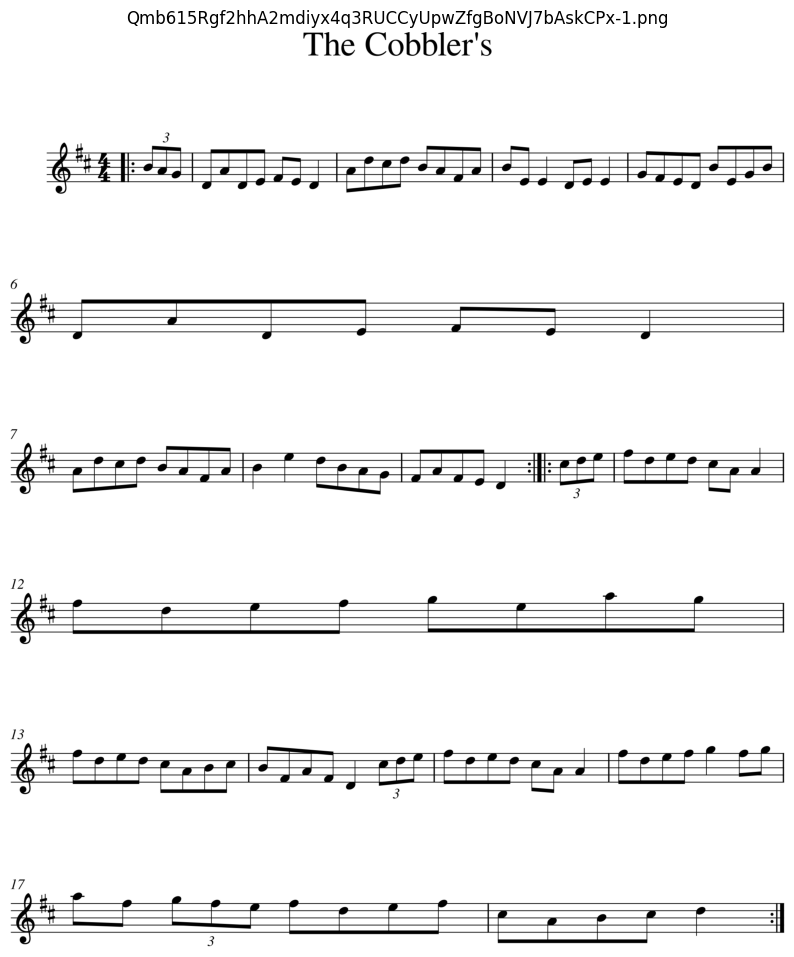

In [18]:
images = sorted(IMAGE_DIR.glob("*.png"))

print("Found images:", len(images))

if not images:
    raise FileNotFoundError("No PNG images found in dataset/images/. Run render_to_images.py first.")

image_path = images[0]
print("Using:", image_path)

bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

if bgr is None:
    raise ValueError(f"Could not read image: {image_path}")

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 12))
plt.imshow(rgb)
plt.axis("off")
plt.title(image_path.name)
plt.show()

In [19]:
def extract_patch_chw(image_chw, y, x, win_size):
    """
    HOMR-style patch extraction.

    image_chw: [C, H, W]
    returns: [C, win_size, win_size]
    """
    c, h, w = image_chw.shape

    patch = np.full(
        (c, win_size, win_size),
        255,
        dtype=image_chw.dtype,
    )

    y0 = max(y, 0)
    x0 = max(x, 0)
    y1 = min(y + win_size, h)
    x1 = min(x + win_size, w)

    py0 = 0
    px0 = 0
    py1 = py0 + (y1 - y0)
    px1 = px0 + (x1 - x0)

    patch[:, py0:py1, px0:px1] = image_chw[:, y0:y1, x0:x1]

    return patch

In [20]:
def merge_patches(patches, image_shape, win_size, step_size):
    """
    HOMR-style merge.

    patches: list of [H, W] class maps
    image_shape: original [H, W]
    """
    reconstructed = np.zeros(image_shape, dtype=np.float32)
    weight = np.zeros(image_shape, dtype=np.float32)

    idx = 0

    for iy in range(0, image_shape[0], step_size):
        y = min(iy, image_shape[0] - win_size)
        y0 = max(y, 0)
        y1 = min(y + win_size, image_shape[0])

        for ix in range(0, image_shape[1], step_size):
            x = min(ix, image_shape[1] - win_size)
            x0 = max(x, 0)
            x1 = min(x + win_size, image_shape[1])

            patch = patches[idx]

            ph = y1 - y0
            pw = x1 - x0

            reconstructed[y0:y1, x0:x1] += patch[:ph, :pw]
            weight[y0:y1, x0:x1] += 1

            idx += 1

    weight[weight == 0] = 1
    reconstructed /= weight

    return reconstructed.astype(patches[0].dtype)

In [21]:
def run_segnet_homr_style(
    image_rgb,
    segnet_session,
    batch_size=8,
    step_size=-1,
    win_size=320,
):
    """
    Runs SegNet the same way HOMR's inference_segnet.py does.
    """

    if step_size < 0:
        step_size = win_size // 2

    input_name = segnet_session.get_inputs()[0].name
    output_name = segnet_session.get_outputs()[0].name

    # HOMR's code receives grayscale, then converts gray -> BGR.
    # For this notebook we already have RGB, so convert to CHW directly.
    image_chw = np.transpose(image_rgb, (2, 0, 1)).astype(np.float32)

    c, h, w = image_chw.shape

    class_patches = []
    batch = []

    for y_loop in range(0, max(h, win_size), step_size):
        y = min(y_loop, h - win_size)

        for x_loop in range(0, max(w, win_size), step_size):
            x = min(x_loop, w - win_size)

            patch = extract_patch_chw(image_chw, y, x, win_size)
            batch.append(patch)

            if len(batch) == batch_size:
                batch_input = np.stack(batch, axis=0).astype(np.float32)

                out = segnet_session.run(
                    [output_name],
                    {input_name: batch_input},
                )[0]

                for patch_out in out:
                    class_patches.append(np.argmax(patch_out, axis=0).astype(np.uint8))

                batch.clear()

    if batch:
        batch_input = np.stack(batch, axis=0).astype(np.float32)

        out = segnet_session.run(
            [output_name],
            {input_name: batch_input},
        )[0]

        for patch_out in out:
            class_patches.append(np.argmax(patch_out, axis=0).astype(np.uint8))

    merged = merge_patches(
        class_patches,
        image_shape=(h, w),
        win_size=win_size,
        step_size=step_size,
    )

    return merged.astype(np.uint8)

In [22]:
class_map = run_segnet_homr_style(
    rgb,
    segnet,
    batch_size=8,
    step_size=-1,
    win_size=320,
)

print("class_map shape:", class_map.shape)
print("unique classes and counts:", np.unique(class_map, return_counts=True))

class_map shape: (2657, 2250)
unique classes and counts: (array([0, 1, 2, 3, 4], dtype=uint8), array([5584796,   29466,   58728,   20373,  284887], dtype=int64))


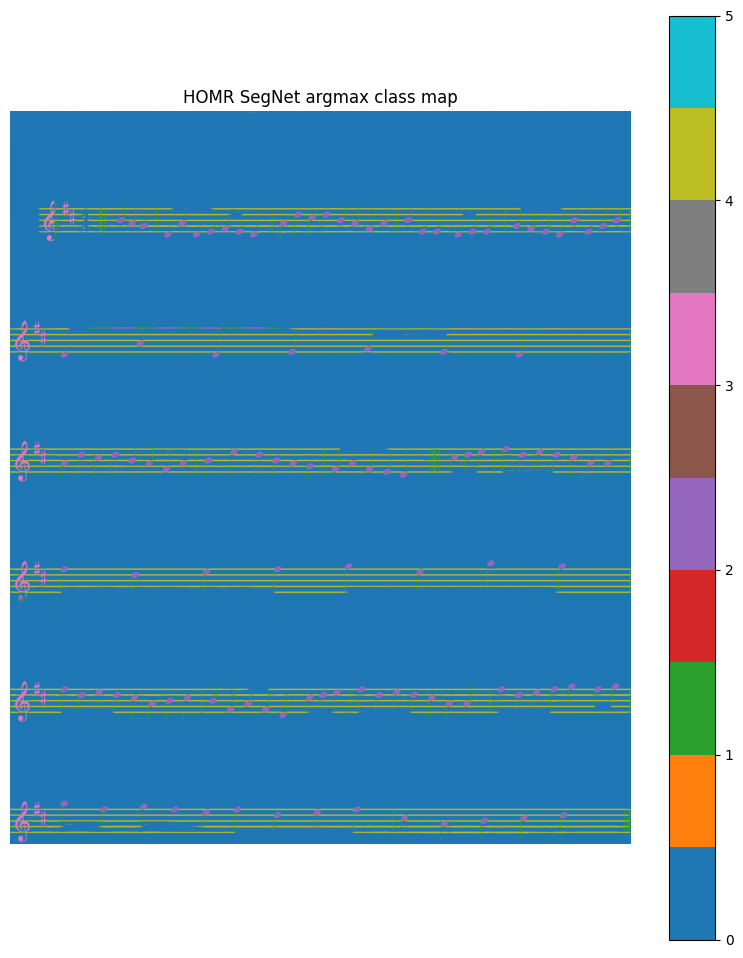

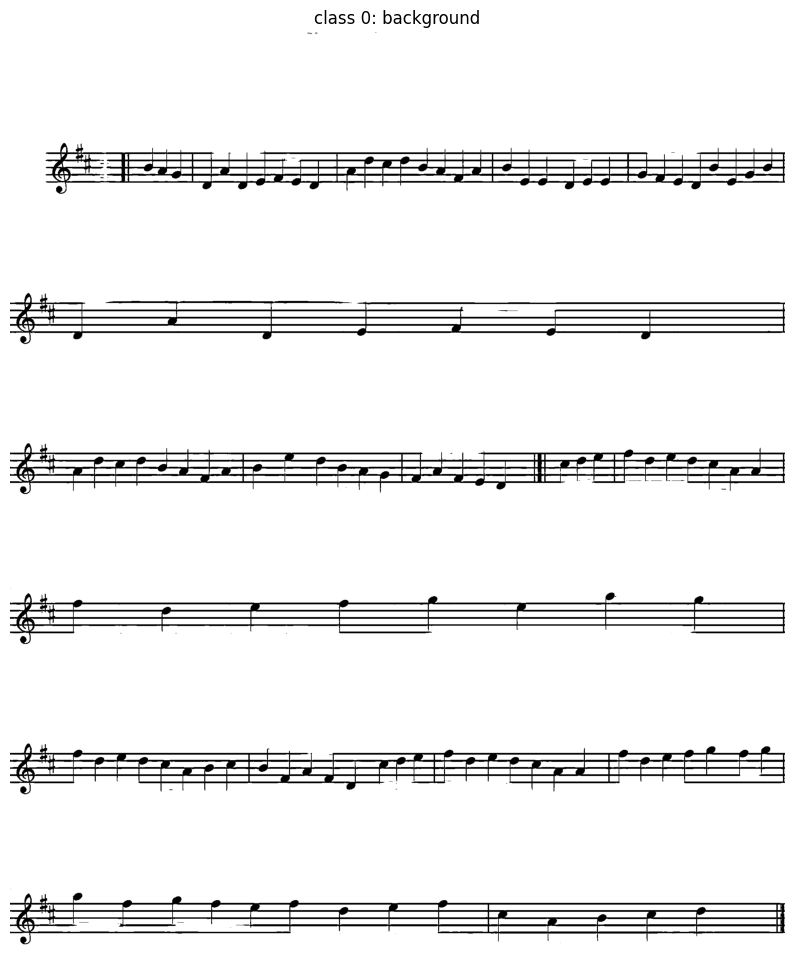

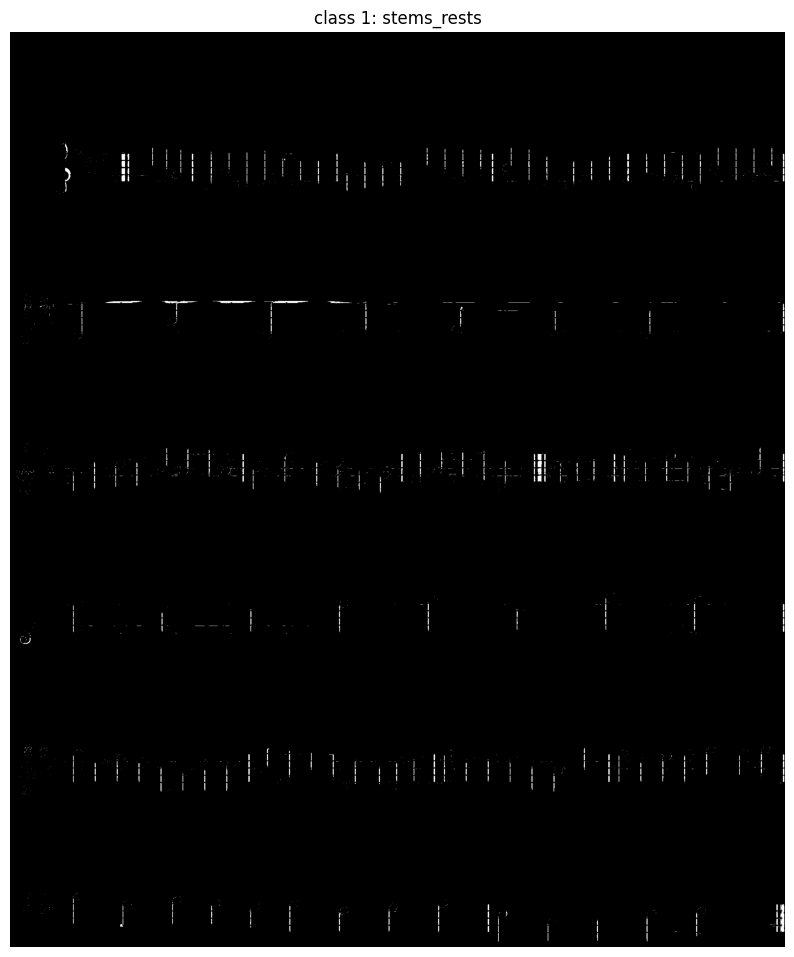

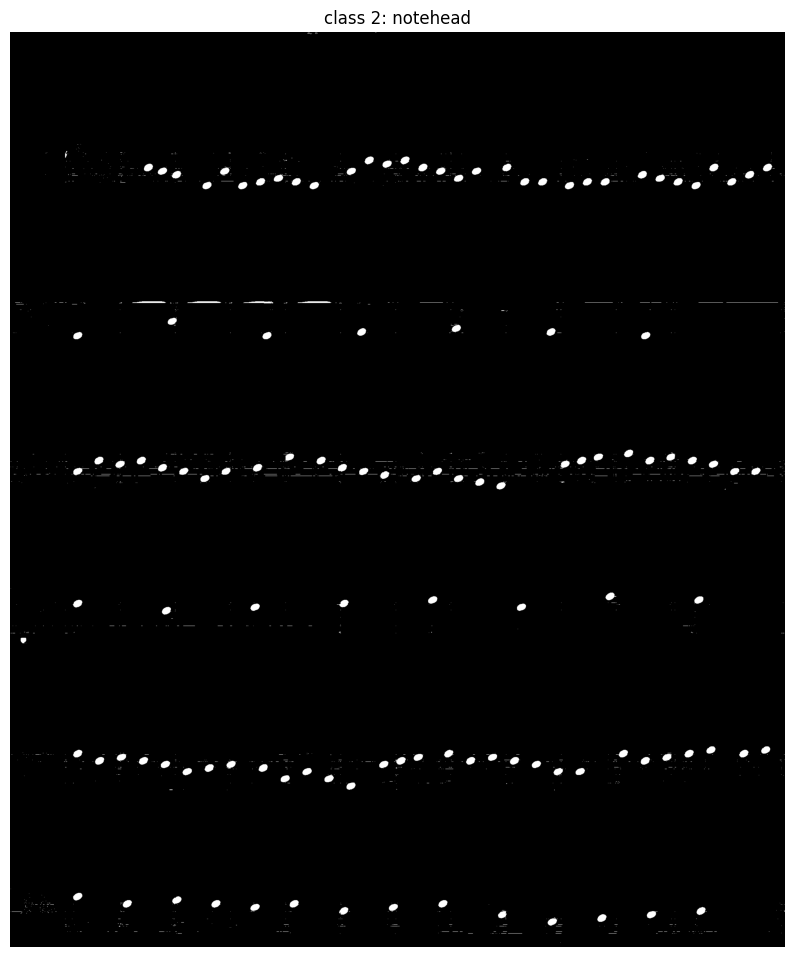

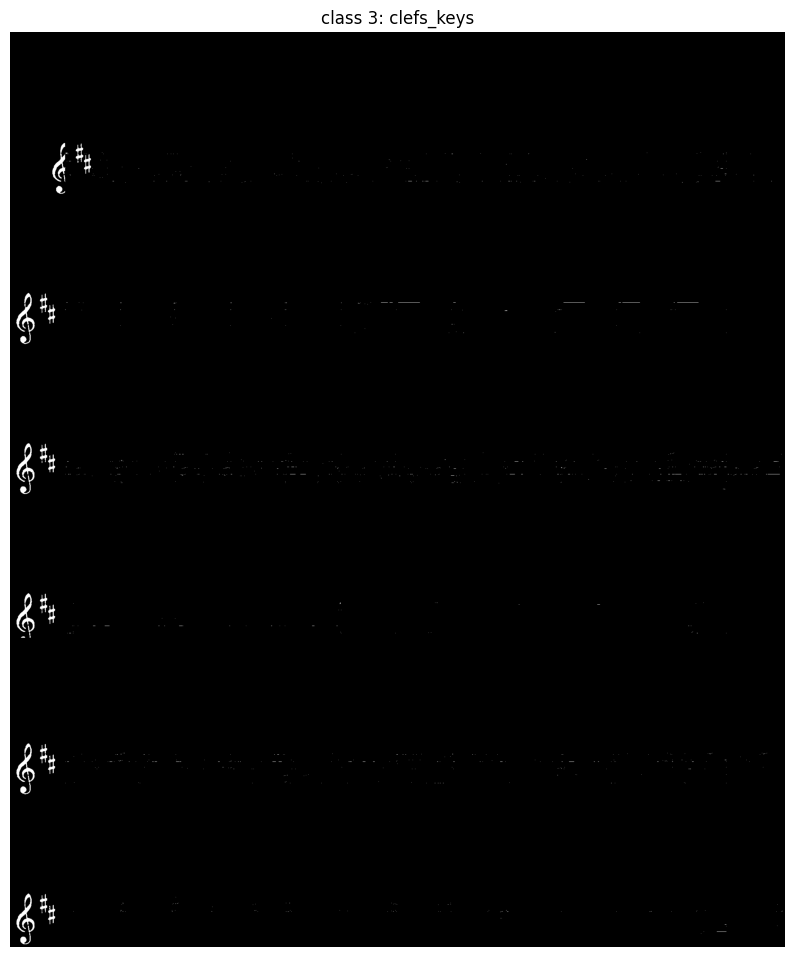

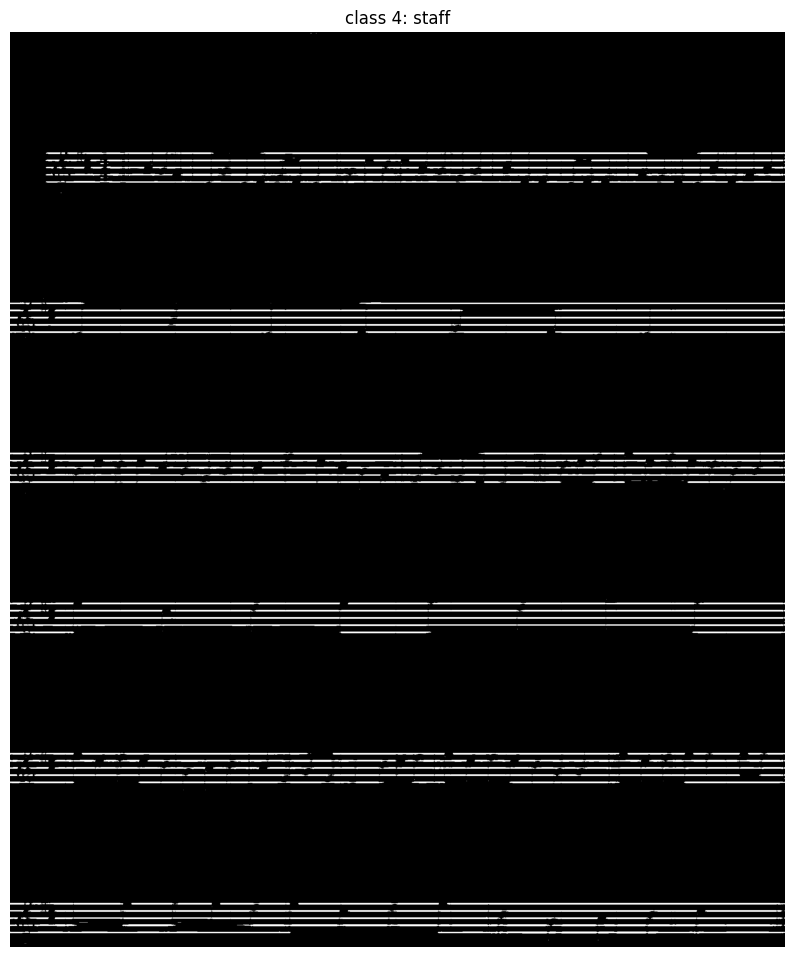

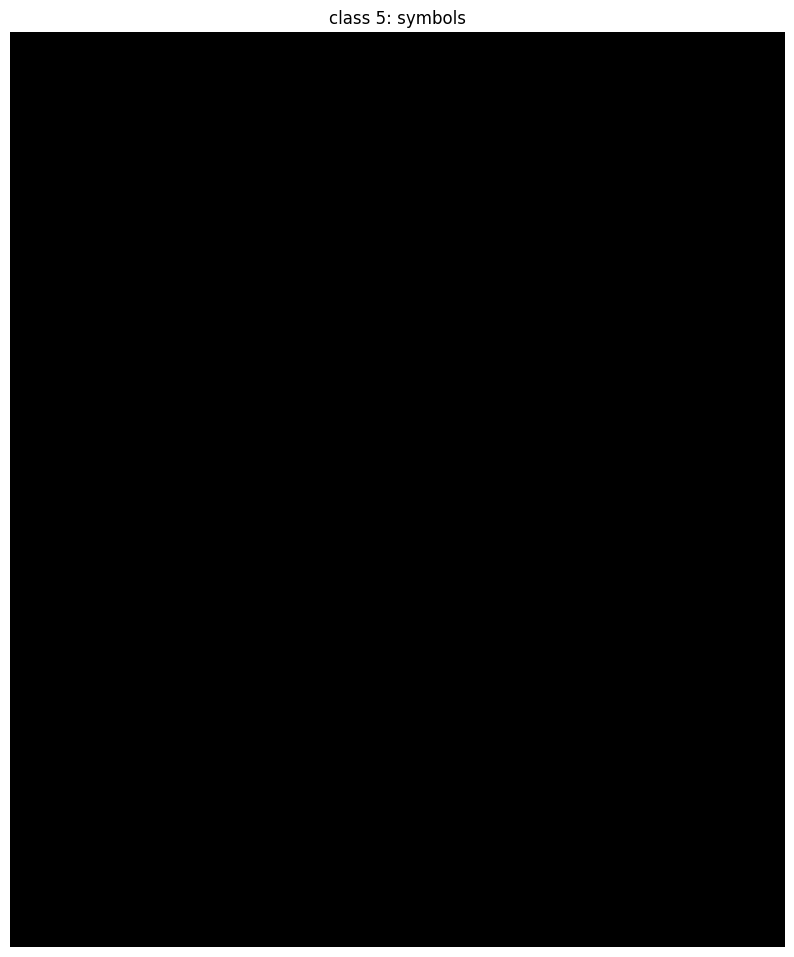

In [23]:
CLASS_NAMES = {
    0: "background",
    1: "stems_rests",
    2: "notehead",
    3: "clefs_keys",
    4: "staff",
    5: "symbols",
}

plt.figure(figsize=(10, 12))
plt.imshow(class_map, cmap="tab10", vmin=0, vmax=5)
plt.colorbar()
plt.axis("off")
plt.title("HOMR SegNet argmax class map")
plt.show()

for class_id, name in CLASS_NAMES.items():
    mask = class_map == class_id

    plt.figure(figsize=(10, 12))
    plt.imshow(mask, cmap="gray")
    plt.axis("off")
    plt.title(f"class {class_id}: {name}")
    plt.show()

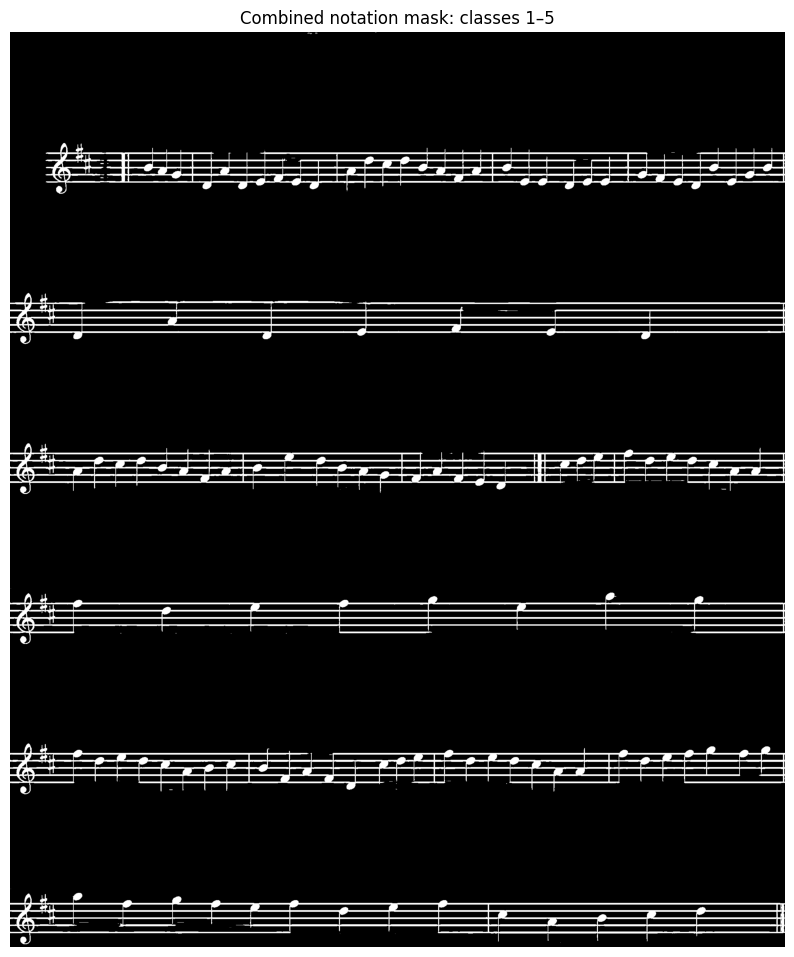

In [24]:
staff_mask = (class_map == 4)
symbol_mask = (class_map == 5)
notehead_mask = (class_map == 2)
stems_rests_mask = (class_map == 1)
clefs_keys_mask = (class_map == 3)

notation_mask = (
    staff_mask
    | symbol_mask
    | notehead_mask
    | stems_rests_mask
    | clefs_keys_mask
)

plt.figure(figsize=(10, 12))
plt.imshow(notation_mask, cmap="gray")
plt.axis("off")
plt.title("Combined notation mask: classes 1–5")
plt.show()

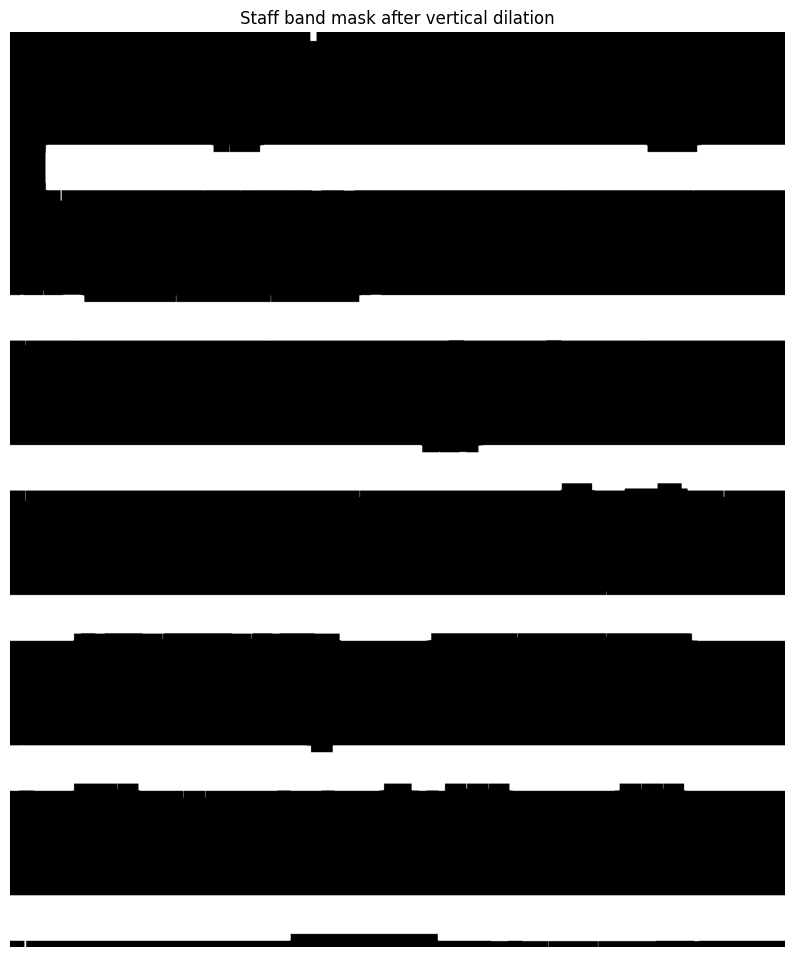

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def build_staff_band_mask(staff_mask, vertical_kernel_height=35, horizontal_kernel_width=25):
    """
    Convert thin staff-line pixels into thicker staff/system bands.

    staff_mask:
        Boolean mask where class 4 == staff lines.

    Returns:
        Boolean mask where each staff region is vertically connected.
    """

    mask = staff_mask.astype(np.uint8) * 255

    # Connect the five thin staff lines into one vertical band.
    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, vertical_kernel_height),
    )

    band = cv2.dilate(mask, vertical_kernel, iterations=1)

    # Connect broken horizontal fragments.
    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (horizontal_kernel_width, 1),
    )

    band = cv2.morphologyEx(band, cv2.MORPH_CLOSE, horizontal_kernel, iterations=1)

    return band > 0


staff_band_mask = build_staff_band_mask(
    staff_mask,
    vertical_kernel_height=45,
    horizontal_kernel_width=35,
)

plt.figure(figsize=(10, 12))
plt.imshow(staff_band_mask, cmap="gray")
plt.axis("off")
plt.title("Staff band mask after vertical dilation")
plt.show()

In [28]:
def extract_vertical_regions_from_band_mask(mask, min_height=25, min_gap=20):
    """
    Extract vertical staff/system regions from a thickened staff-band mask.
    """

    row_sums = mask.astype(np.uint8).sum(axis=1)

    active = row_sums > 0

    raw_regions = []

    in_region = False
    start = None

    for y, val in enumerate(active):
        if val and not in_region:
            start = y
            in_region = True
        elif not val and in_region:
            raw_regions.append((start, y))
            in_region = False

    if in_region:
        raw_regions.append((start, len(active) - 1))

    # Merge regions separated by tiny vertical gaps.
    merged = []

    for region in raw_regions:
        if not merged:
            merged.append(region)
            continue

        prev_start, prev_end = merged[-1]
        cur_start, cur_end = region

        if cur_start - prev_end <= min_gap:
            merged[-1] = (prev_start, cur_end)
        else:
            merged.append(region)

    # Remove tiny artifacts.
    regions = [
        (y0, y1)
        for y0, y1 in merged
        if y1 - y0 >= min_height
    ]

    return regions


regions = extract_vertical_regions_from_band_mask(
    staff_band_mask,
    min_height=25,
    min_gap=20,
)

print("regions:", regions)
print("number of regions:", len(regions))

regions: [(0, 29), (330, 492), (753, 911), (1201, 1363), (1626, 1769), (2071, 2224), (2507, 2656)]
number of regions: 7


Extracted crops: 7


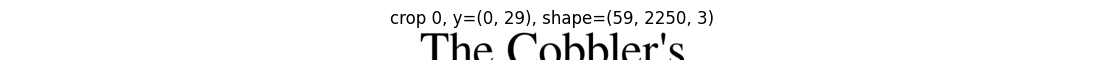

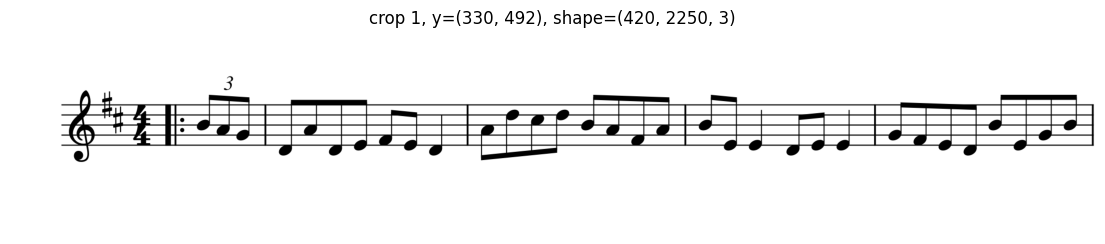

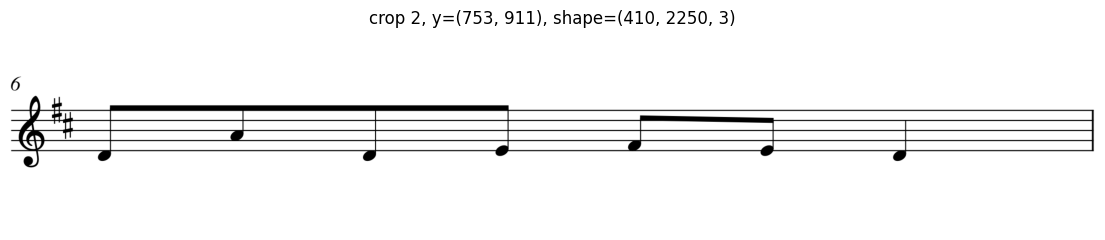

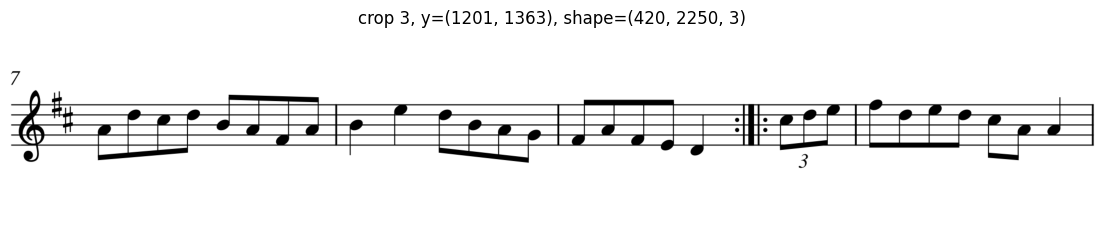

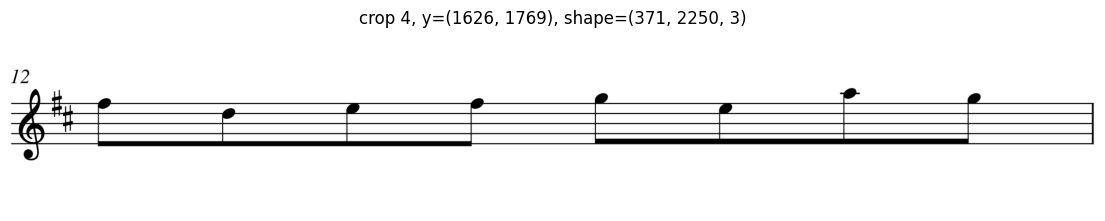

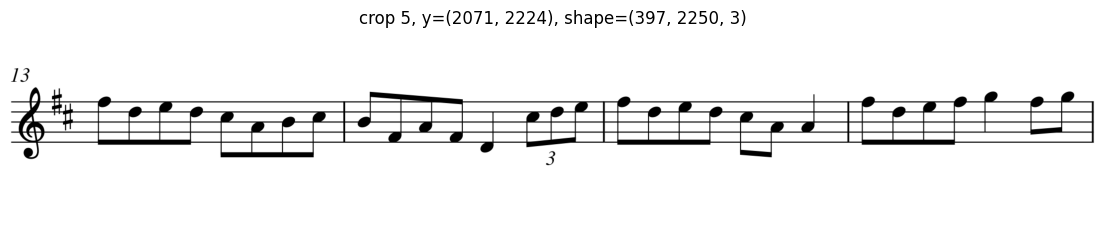

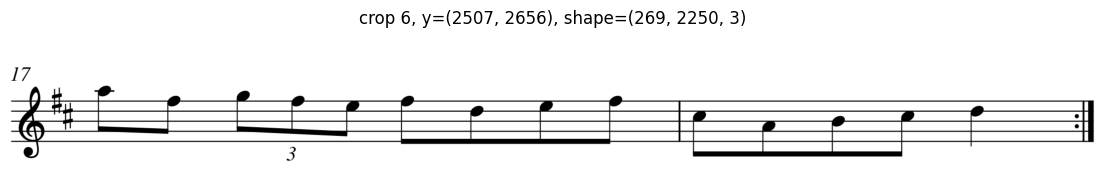

In [29]:
crops = []

for y0, y1 in regions:
    pad = max(30, int((y1 - y0) * 0.8))

    yy0 = max(0, y0 - pad)
    yy1 = min(rgb.shape[0], y1 + pad)

    crop = rgb[yy0:yy1, :]
    crops.append(crop)

print("Extracted crops:", len(crops))

for idx, crop in enumerate(crops):
    plt.figure(figsize=(14, 4))
    plt.imshow(crop)
    plt.axis("off")
    plt.title(f"crop {idx}, y={regions[idx]}, shape={crop.shape}")
    plt.show()

In [31]:
import sys
from pathlib import Path

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "attacks":
    ROOT = ROOT.parent

ROOT = ROOT.resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
print("ROOT on sys.path:", str(ROOT) in sys.path)

ROOT: D:\Users\theda\Documents\dev\Projects\Uni\Semester 4\Artificial Intelligence\adversarial-homr
ROOT on sys.path: True


crops: 7


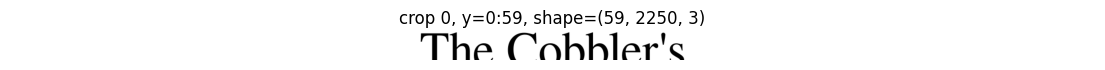

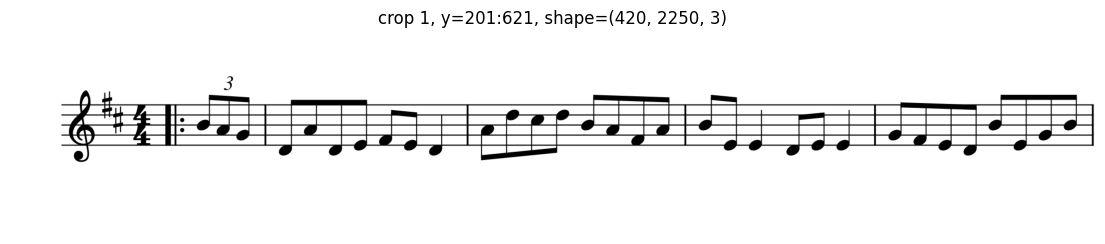

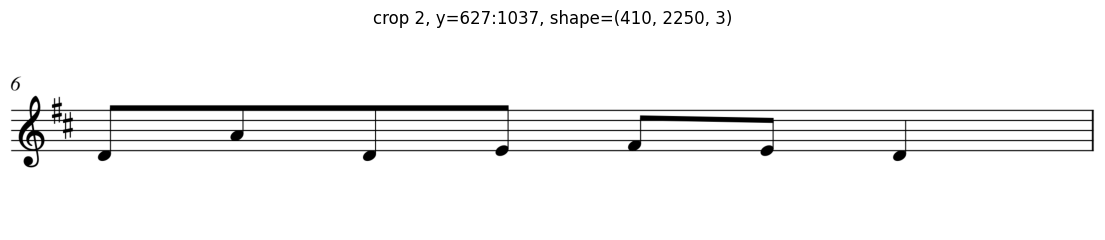

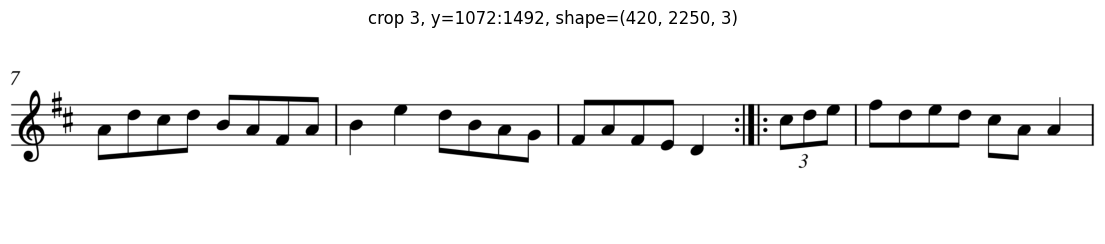

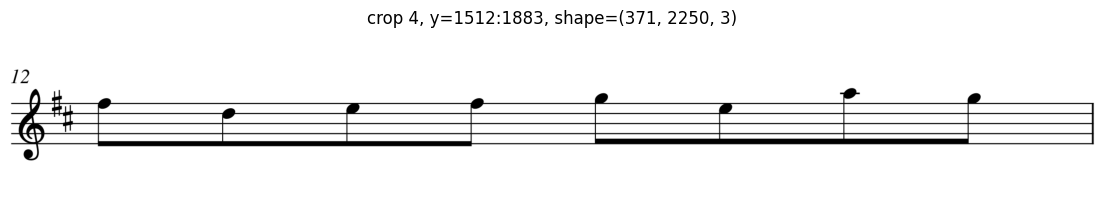

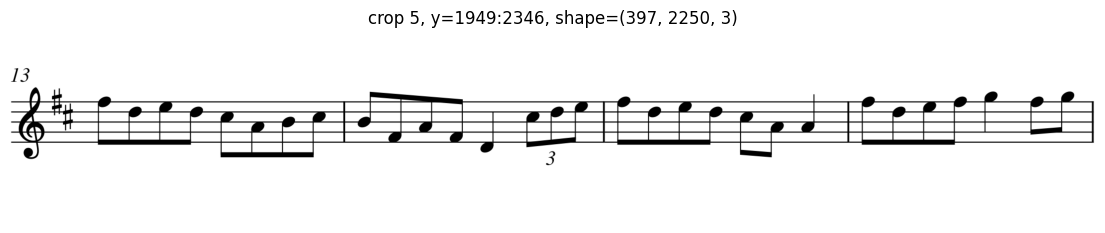

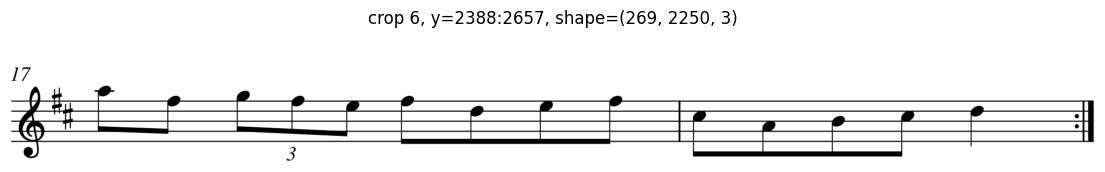

In [32]:
from attacks.src.segmentation_onnx import SegNetONNX, extract_staff_crops_from_class_map

seg = SegNetONNX(
    model_path=ROOT / "models" / "onnx" / "segnet.onnx",
    use_cuda=True,
    batch_size=8,
)

class_map = seg.predict_class_map(rgb)

crop_items = extract_staff_crops_from_class_map(
    image_rgb=rgb,
    class_map=class_map,
)

print("crops:", len(crop_items))

for item in crop_items:
    crop = item["crop"]

    plt.figure(figsize=(14, 4))
    plt.imshow(crop)
    plt.axis("off")
    plt.title(f"crop {item['index']}, y={item['y0']}:{item['y1']}, shape={crop.shape}")
    plt.show()